# Ablation Study: Matrix Factorization Recommender System

Comprehensive ablation studies on the ALS-based MF model using MovieLens 32M.
Training limited to 20 iterations for fast experimentation.

**Studies included:**
1. Latent Dimension (K) Analysis
2. Optuna Hyperparameter Optimization
3. Time-based vs Random Split Comparison
4. Convergence Analysis
5. Cold-Start Performance by Popularity
6. Bias vs Latent Factor Contribution
7. Latent Factor Embedding Analysis

In [1]:
# Setup and Imports
import sys, os, time, warnings
warnings.filterwarnings('ignore')

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from src.data_loader import MovieLensDataset
from src.data_structures import RatingMatrix
from src.train_test_split import time_based_split, random_split
from src.als import MatrixFactorizationModel

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

FIGURE_DIR = os.path.join(project_root, 'report', 'figures', 'ablation')
os.makedirs(FIGURE_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIGURE_DIR}")

Figures will be saved to: c:\Users\ayman\Downloads\aims\Applied ML at Scale\project\report\figures\ablation


In [2]:
# Configuration
N_ITERS = 20
TEST_RATIO = 0.2
RANDOM_SEED = 42

# Default hyperparameters
DEFAULT_K = 20
DEFAULT_LAMBDA = 0.00235
DEFAULT_TAU = 0.0631
DEFAULT_GAMMA = 0.0132

## Data Loading

In [3]:
data_path = os.path.join(project_root, 'data', 'ml-32m')
dataset = MovieLensDataset(data_path)
print(dataset.summary())

user_idx, item_idx, ratings, timestamps = dataset.get_arrays_with_timestamps()
print(f"\nLoaded {len(ratings):,} ratings")

Loading ratings from c:\Users\ayman\Downloads\aims\Applied ML at Scale\project\data\ml-32m\ratings.csv...
Loaded 32,000,204 ratings
MovieLens Dataset Summary
Users:          200,948
Items:           84,432
Ratings:     32,000,204
Sparsity:      99.8114%
Mean:             3.540


Loaded 32,000,204 ratings


In [4]:
# RANDOM split as default for ablation studies
train_data, test_data = random_split(user_idx, item_idx, ratings, TEST_RATIO, seed=RANDOM_SEED)
train_users, train_items, train_ratings = train_data
test_users, test_items, test_ratings = test_data

print(f"Train set: {len(train_ratings):,} ratings")
print(f"Test set:  {len(test_ratings):,} ratings")

rating_matrix = RatingMatrix(train_users, train_items, train_ratings, 
                             dataset.n_users, dataset.n_items)

Train set: 25,600,163 ratings
Test set:  6,400,041 ratings


## Section 2: Hyperparameter Optimization - Random Split

We first run Optuna HPO on the random split to find optimal hyperparameters.

In [5]:
# HPO for Random Split
def objective_rand(trial):
    K = trial.suggest_categorical('K', [20, 30])
    lambda_ = trial.suggest_float('lambda', 0.0001, 1.0, log=True)
    tau = trial.suggest_float('tau', 0.001, 1.0, log=True)
    gamma = trial.suggest_float('gamma', 0.001, 1.0, log=True)
    
    model = MatrixFactorizationModel(K=K, lambda_=lambda_, tau=tau, gamma=gamma,
                                     n_iters=10, verbose=True)
    model.fit(rating_matrix, test_data=test_data)
    return model.test_rmse_history[-1]

print("Running Optuna HPO for Random Split (15 trials)...")
study_rand = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_rand.optimize(objective_rand, n_trials=15, show_progress_bar=True)

best_params_rand = study_rand.best_params
print(f"\nRandom Split - Best RMSE: {study_rand.best_value:.4f}")
print(f"Best params: {best_params_rand}")

Running Optuna HPO for Random Split (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]

Iter 1: Loss=648076.60, Train RMSE=0.7508, Test RMSE=0.9290 (30.10s)
Iter 2: Loss=537168.49, Train RMSE=0.6793, Test RMSE=0.8774 (9.75s)
Iter 3: Loss=489374.89, Train RMSE=0.6478, Test RMSE=0.8533 (9.33s)
Iter 4: Loss=464924.05, Train RMSE=0.6317, Test RMSE=0.8421 (9.16s)
Iter 5: Loss=450439.31, Train RMSE=0.6223, Test RMSE=0.8367 (10.29s)
Iter 6: Loss=440871.86, Train RMSE=0.6162, Test RMSE=0.8338 (10.09s)
Iter 7: Loss=434047.16, Train RMSE=0.6120, Test RMSE=0.8324 (9.40s)
Iter 8: Loss=428911.83, Train RMSE=0.6089, Test RMSE=0.8317 (9.49s)
Iter 9: Loss=424897.05, Train RMSE=0.6066, Test RMSE=0.8315 (9.48s)
Iter 10: Loss=421669.99, Train RMSE=0.6047, Test RMSE=0.8316 (9.44s)
Iter 1: Loss=2341588.58, Train RMSE=0.7781, Test RMSE=0.9368 (5.37s)
Iter 2: Loss=2040947.80, Train RMSE=0.7256, Test RMSE=0.8935 (5.32s)
Iter 3: Loss=1855977.13, Train RMSE=0.6914, Test RMSE=0.8608 (5.63s)
Iter 4: Loss=1759614.39, Train RMSE=0.6732, Test RMSE=0.8442 (5.52s)
Iter 5: Loss=1704783.53, Train RMSE=0.66

---
## Section 3: Hyperparameter Optimization - Time-Based Split

We run a separate Optuna HPO on the time-based split for fair comparison.

In [6]:
# Create time-based split
train_time, test_time = time_based_split(user_idx, item_idx, ratings, timestamps, TEST_RATIO)
rm_time = RatingMatrix(train_time[0], train_time[1], train_time[2], dataset.n_users, dataset.n_items)

print(f"Time-based split: {len(train_time[2]):,} train, {len(test_time[2]):,} test")

Time-based split: 25,600,163 train, 6,400,041 test


In [7]:
# HPO for Time-Based Split  
def objective_time(trial):
    K = trial.suggest_categorical('K', [20, 30])
    lambda_ = trial.suggest_float('lambda', 0.0001, 1.0, log=True)
    tau = trial.suggest_float('tau', 0.001, 1.0, log=True)
    gamma = trial.suggest_float('gamma', 0.001, 1.0, log=True)
    
    model = MatrixFactorizationModel(K=K, lambda_=lambda_, tau=tau, gamma=gamma,
                                     n_iters=10, verbose=True)
    model.fit(rm_time, test_data=test_time)
    return model.test_rmse_history[-1]

print("Running Optuna HPO for Time-Based Split (15 trials)...")
study_time = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_time.optimize(objective_time, n_trials=15, show_progress_bar=True)

best_params_time = study_time.best_params
print(f"\nTime-Based Split - Best RMSE: {study_time.best_value:.4f}")
print(f"Best params: {best_params_time}")

Running Optuna HPO for Time-Based Split (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]

Iter 1: Loss=668441.85, Train RMSE=0.7657, Test RMSE=0.9872 (10.44s)
Iter 2: Loss=552525.35, Train RMSE=0.6922, Test RMSE=0.9808 (10.29s)
Iter 3: Loss=506128.40, Train RMSE=0.6620, Test RMSE=0.9787 (10.04s)
Iter 4: Loss=483403.43, Train RMSE=0.6472, Test RMSE=0.9780 (10.26s)
Iter 5: Loss=470101.80, Train RMSE=0.6388, Test RMSE=0.9778 (10.56s)
Iter 6: Loss=461302.60, Train RMSE=0.6333, Test RMSE=0.9778 (10.01s)
Iter 7: Loss=454990.66, Train RMSE=0.6296, Test RMSE=0.9779 (10.43s)
Iter 8: Loss=450208.32, Train RMSE=0.6268, Test RMSE=0.9780 (9.91s)
Iter 9: Loss=446446.90, Train RMSE=0.6246, Test RMSE=0.9782 (10.15s)
Iter 10: Loss=443408.18, Train RMSE=0.6229, Test RMSE=0.9784 (10.05s)
Iter 1: Loss=2419635.74, Train RMSE=0.7937, Test RMSE=0.9885 (6.08s)
Iter 2: Loss=2092482.41, Train RMSE=0.7371, Test RMSE=0.9828 (6.02s)
Iter 3: Loss=1904156.58, Train RMSE=0.7026, Test RMSE=0.9800 (6.08s)
Iter 4: Loss=1814013.34, Train RMSE=0.6856, Test RMSE=0.9789 (5.92s)
Iter 5: Loss=1764039.02, Train RMS

---
## Section 4: HPO Results Comparison

Compare the optimal hyperparameters found for each split strategy.

In [8]:
# Summary comparison
print("=" * 60)
print("HPO RESULTS COMPARISON")
print("=" * 60)
print(f"\nRandom Split:")
print(f"  Best RMSE: {study_rand.best_value:.4f}")
for k, v in best_params_rand.items():
    print(f"  {k}: {v:.6f}" if isinstance(v, float) else f"  {k}: {v}")

print(f"\nTime-Based Split:")
print(f"  Best RMSE: {study_time.best_value:.4f}")
for k, v in best_params_time.items():
    print(f"  {k}: {v:.6f}" if isinstance(v, float) else f"  {k}: {v}")

HPO RESULTS COMPARISON

Random Split:
  Best RMSE: 0.7811
  K: 20
  lambda: 0.001474
  tau: 0.012563
  gamma: 0.023346

Time-Based Split:
  Best RMSE: 0.9690
  K: 20
  lambda: 0.001474
  tau: 0.012563
  gamma: 0.023346


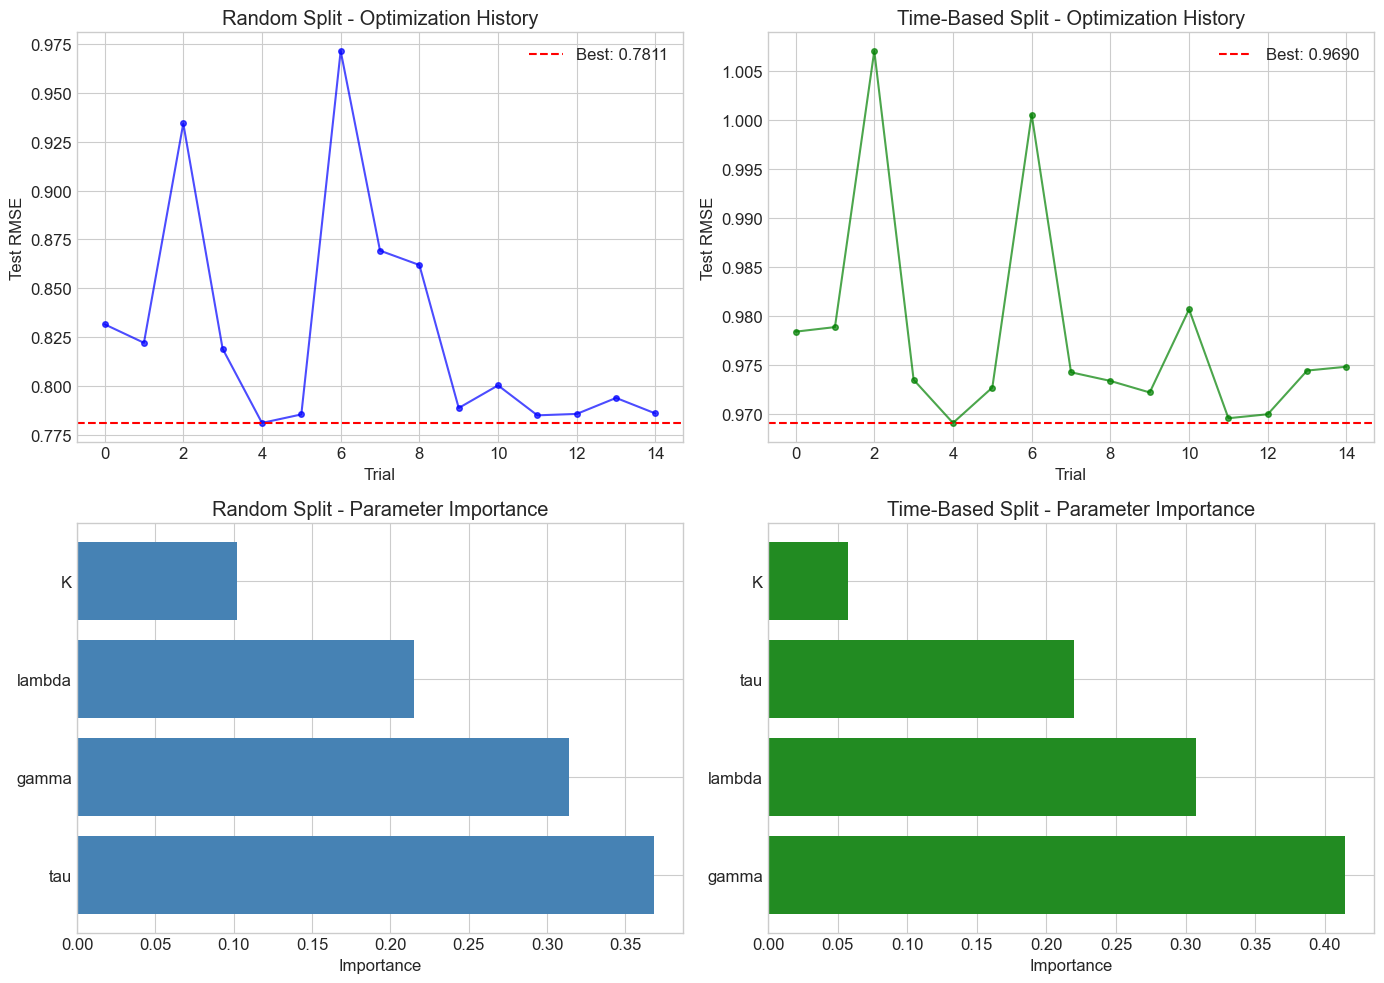

In [9]:
# Optuna Visualization - Random Split
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Random split plots
ax = axes[0, 0]
trials_rand = [t.value for t in study_rand.trials if t.value is not None]
ax.plot(trials_rand, 'b-o', markersize=4, alpha=0.7)
ax.axhline(y=study_rand.best_value, color='r', linestyle='--', label=f'Best: {study_rand.best_value:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Test RMSE')
ax.set_title('Random Split - Optimization History')
ax.legend()

ax = axes[0, 1]
trials_time = [t.value for t in study_time.trials if t.value is not None]
ax.plot(trials_time, 'g-o', markersize=4, alpha=0.7)
ax.axhline(y=study_time.best_value, color='r', linestyle='--', label=f'Best: {study_time.best_value:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Test RMSE')
ax.set_title('Time-Based Split - Optimization History')
ax.legend()

# Parameter importance (if available)
try:
    importances_rand = optuna.importance.get_param_importances(study_rand)
    ax = axes[1, 0]
    ax.barh(list(importances_rand.keys()), list(importances_rand.values()), color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title('Random Split - Parameter Importance')
except:
    axes[1, 0].text(0.5, 0.5, 'Not enough trials for importance', ha='center', va='center')
    axes[1, 0].set_title('Random Split - Parameter Importance')

try:
    importances_time = optuna.importance.get_param_importances(study_time)
    ax = axes[1, 1]
    ax.barh(list(importances_time.keys()), list(importances_time.values()), color='forestgreen')
    ax.set_xlabel('Importance')
    ax.set_title('Time-Based Split - Parameter Importance')
except:
    axes[1, 1].text(0.5, 0.5, 'Not enough trials for importance', ha='center', va='center')
    axes[1, 1].set_title('Time-Based Split - Parameter Importance')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'hpo_comparison.pdf'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5: Train Models with Optimal Hyperparameters

Train the final models using the best hyperparameters found by HPO for each split.

In [10]:
# Train models with their respective best params
print("Training models with optimal hyperparameters...")

# Random split model with random split best params
print("\nRandom split model:")
model_rand = MatrixFactorizationModel(
    K=best_params_rand['K'], 
    lambda_=best_params_rand['lambda'], 
    tau=best_params_rand['tau'],
    gamma=best_params_rand['gamma'], 
    n_iters=N_ITERS, 
    verbose=True
)
model_rand.fit(rating_matrix, test_data=test_data)

# Time-based split model with time-based best params
print("\nTime-based split model:")
model_time = MatrixFactorizationModel(
    K=best_params_time['K'],
    lambda_=best_params_time['lambda'], 
    tau=best_params_time['tau'], 
    gamma=best_params_time['gamma'], 
    n_iters=N_ITERS, 
    verbose=True
)
model_time.fit(rm_time, test_data=test_time)

# Alias for backward compatibility
rm_rand = rating_matrix
train_rand, test_rand = train_data, test_data

Training models with optimal hyperparameters...

Random split model:
Iter 1: Loss=13257.03, Train RMSE=0.8147, Test RMSE=0.8853 (5.74s)
Iter 2: Loss=11047.55, Train RMSE=0.7270, Test RMSE=0.8357 (5.55s)
Iter 3: Loss=10238.07, Train RMSE=0.6965, Test RMSE=0.8079 (5.31s)
Iter 4: Loss=9903.46, Train RMSE=0.6838, Test RMSE=0.7962 (5.10s)
Iter 5: Loss=9727.40, Train RMSE=0.6772, Test RMSE=0.7901 (5.24s)
Iter 6: Loss=9621.43, Train RMSE=0.6733, Test RMSE=0.7866 (5.15s)
Iter 7: Loss=9552.22, Train RMSE=0.6708, Test RMSE=0.7843 (5.27s)
Iter 8: Loss=9504.61, Train RMSE=0.6692, Test RMSE=0.7829 (5.10s)
Iter 9: Loss=9470.58, Train RMSE=0.6680, Test RMSE=0.7818 (5.09s)
Iter 10: Loss=9445.45, Train RMSE=0.6671, Test RMSE=0.7811 (5.15s)
Iter 11: Loss=9426.39, Train RMSE=0.6665, Test RMSE=0.7806 (5.20s)
Iter 12: Loss=9411.61, Train RMSE=0.6660, Test RMSE=0.7802 (5.24s)
Iter 13: Loss=9399.90, Train RMSE=0.6656, Test RMSE=0.7799 (5.23s)
Iter 14: Loss=9390.41, Train RMSE=0.6654, Test RMSE=0.7797 (5.35s)

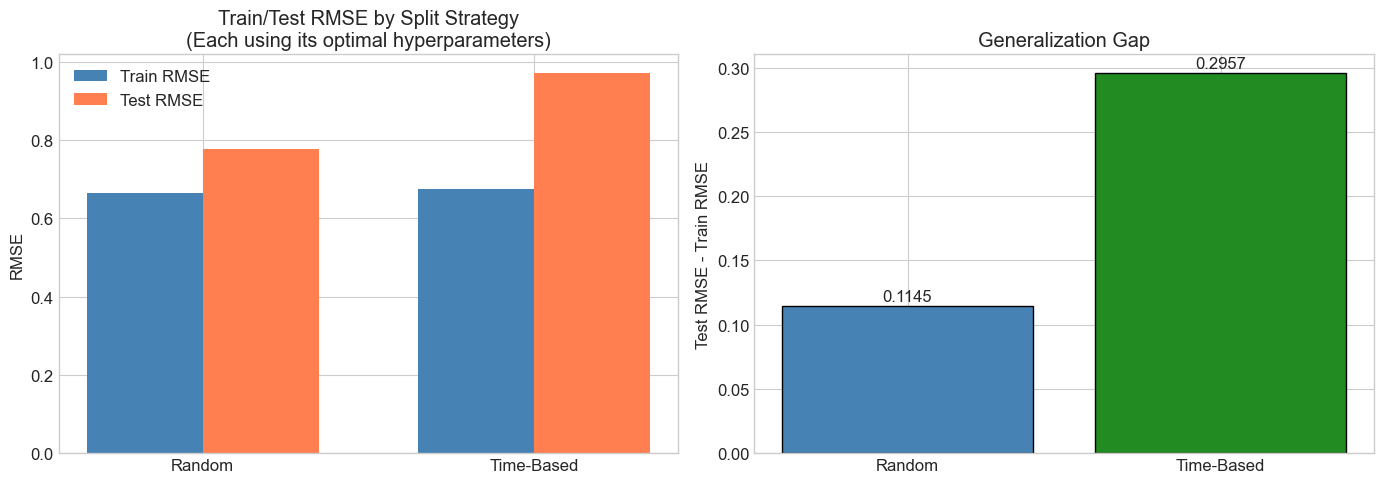


Split Comparison Summary (with respective optimal hyperparameters):
     Split  K  Train RMSE  Test RMSE      Gap
    Random 20    0.664409   0.778869 0.114460
Time-Based 20    0.675401   0.971126 0.295725


In [11]:
# Split comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train/Test RMSE comparison
splits = ['Random', 'Time-Based']
train_rmses = [model_rand.train_rmse_history[-1], model_time.train_rmse_history[-1]]
test_rmses = [model_rand.test_rmse_history[-1], model_time.test_rmse_history[-1]]

x = np.arange(len(splits))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, train_rmses, width, label='Train RMSE', color='steelblue')
ax.bar(x + width/2, test_rmses, width, label='Test RMSE', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel('RMSE')
ax.set_title('Train/Test RMSE by Split Strategy\n(Each using its optimal hyperparameters)')
ax.legend()

# Generalization gap comparison
ax = axes[1]
gaps = [test_rmses[i] - train_rmses[i] for i in range(len(splits))]
ax.bar(splits, gaps, color=['steelblue', 'forestgreen'], edgecolor='black')
ax.set_ylabel('Test RMSE - Train RMSE')
ax.set_title('Generalization Gap')
for i, gap in enumerate(gaps):
    ax.text(i, gap + 0.002, f'{gap:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'split_comparison.pdf'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\nSplit Comparison Summary (with respective optimal hyperparameters):")
split_df = pd.DataFrame({
    'Split': splits,
    'K': [best_params_rand['K'], best_params_time['K']],
    'Train RMSE': train_rmses,
    'Test RMSE': test_rmses,
    'Gap': gaps
})
print(split_df.to_string(index=False))

---
## Section 6: Latent Dimension Study

Analyze the effect of latent factor dimensionality K using the optimal regularization parameters from random split HPO.

In [12]:
# Latent dimension study with optimal regularization from HPO
K_values = [5, 10, 20, 40, 80]
k_results = []

for K in K_values:
    print(f"Training K={K}...")
    model = MatrixFactorizationModel(
        K=K, 
        lambda_=best_params_rand['lambda'], 
        tau=best_params_rand['tau'],
        gamma=best_params_rand['gamma'], 
        n_iters=N_ITERS, 
        verbose=True
    )
    model.fit(rating_matrix, test_data=test_data)
    k_results.append({
        'K': K,
        'train_rmse': model.train_rmse_history[-1],
        'test_rmse': model.test_rmse_history[-1]
    })

k_df = pd.DataFrame(k_results)
print("\nLatent Dimension Study Results:")
print(k_df.to_string(index=False))

Training K=5...
Iter 1: Loss=14091.30, Train RMSE=0.8488, Test RMSE=0.8724 (1.33s)
Iter 2: Loss=12663.20, Train RMSE=0.7991, Test RMSE=0.8336 (1.31s)
Iter 3: Loss=12039.22, Train RMSE=0.7773, Test RMSE=0.8128 (1.32s)
Iter 4: Loss=11753.22, Train RMSE=0.7672, Test RMSE=0.8031 (1.25s)
Iter 5: Loss=11611.68, Train RMSE=0.7622, Test RMSE=0.7984 (1.24s)
Iter 6: Loss=11540.41, Train RMSE=0.7598, Test RMSE=0.7962 (1.33s)
Iter 7: Loss=11500.60, Train RMSE=0.7586, Test RMSE=0.7951 (1.33s)
Iter 8: Loss=11475.64, Train RMSE=0.7579, Test RMSE=0.7944 (1.28s)
Iter 9: Loss=11458.72, Train RMSE=0.7574, Test RMSE=0.7940 (1.19s)
Iter 10: Loss=11446.74, Train RMSE=0.7571, Test RMSE=0.7937 (1.19s)
Iter 11: Loss=11438.04, Train RMSE=0.7569, Test RMSE=0.7935 (1.20s)
Iter 12: Loss=11431.57, Train RMSE=0.7568, Test RMSE=0.7934 (1.18s)
Iter 13: Loss=11426.68, Train RMSE=0.7567, Test RMSE=0.7933 (1.18s)
Iter 14: Loss=11422.90, Train RMSE=0.7566, Test RMSE=0.7932 (1.22s)
Iter 15: Loss=11419.94, Train RMSE=0.7566

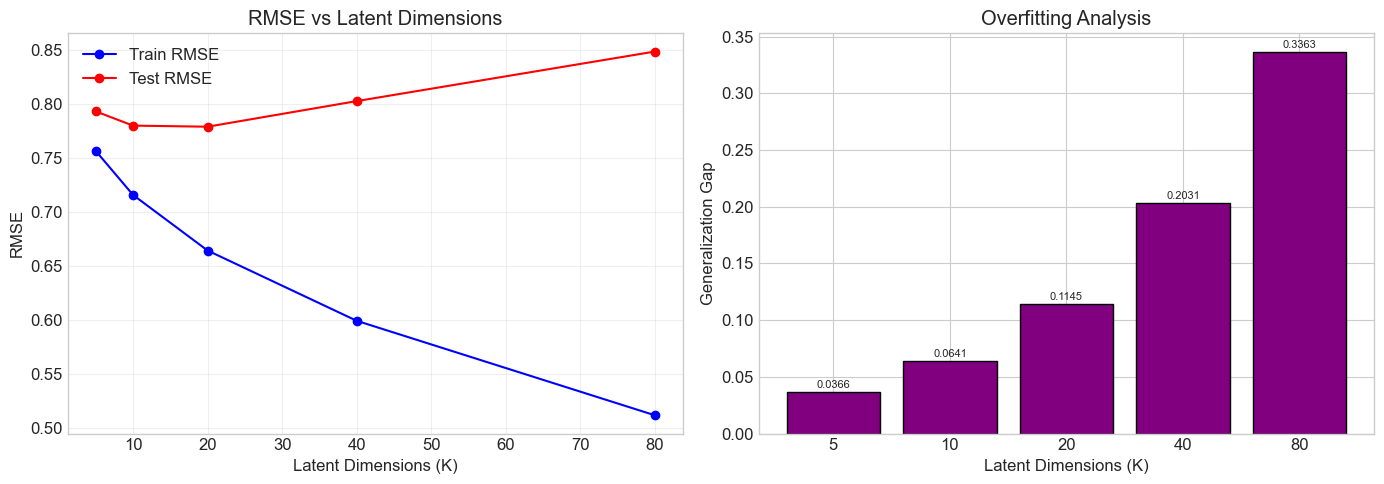

In [13]:
# Latent dimension visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(k_df['K'], k_df['train_rmse'], 'b-o', label='Train RMSE')
ax.plot(k_df['K'], k_df['test_rmse'], 'r-o', label='Test RMSE')
ax.set_xlabel('Latent Dimensions (K)')
ax.set_ylabel('RMSE')
ax.set_title('RMSE vs Latent Dimensions')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
gaps = k_df['test_rmse'] - k_df['train_rmse']
ax.bar([str(k) for k in k_df['K']], gaps, color='purple', edgecolor='black')
ax.set_xlabel('Latent Dimensions (K)')
ax.set_ylabel('Generalization Gap')
ax.set_title('Overfitting Analysis')
for i, (k, gap) in enumerate(zip(k_df['K'], gaps)):
    ax.text(i, gap + 0.002, f'{gap:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'latent_dimension_study.pdf'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7: Popularity Bias Analysis

Analyze model performance across item popularity bins.

In [14]:
# Compute item popularity from training data
item_counts = np.bincount(train_rand[1], minlength=dataset.n_items)

# Bin items by popularity
popularity_bins = [0, 10, 50, 100, 500, np.inf]
bin_labels = ['1-10', '11-50', '51-100', '101-500', '500+']

# Get predictions and errors for test set
test_preds = model_rand.predict(test_rand[0], test_rand[1])
test_errors = (test_rand[2] - test_preds) ** 2
test_item_pop = item_counts[test_rand[1]]

# Compute RMSE per popularity bin
bin_results = []
for i in range(len(bin_labels)):
    lo, hi = popularity_bins[i], popularity_bins[i+1]
    mask = (test_item_pop > lo) & (test_item_pop <= hi)
    if mask.sum() > 0:
        rmse = np.sqrt(np.mean(test_errors[mask]))
        bin_results.append({'bin': bin_labels[i], 'count': mask.sum(), 'rmse': rmse})

pop_df = pd.DataFrame(bin_results)
print("Popularity Bias Analysis:")
print(pop_df.to_string(index=False))

Popularity Bias Analysis:
    bin   count     rmse
   1-10   38646 0.925840
  11-50   74361 0.857465
 51-100   60602 0.835131
101-500  323033 0.793890
   500+ 5898652 0.775122


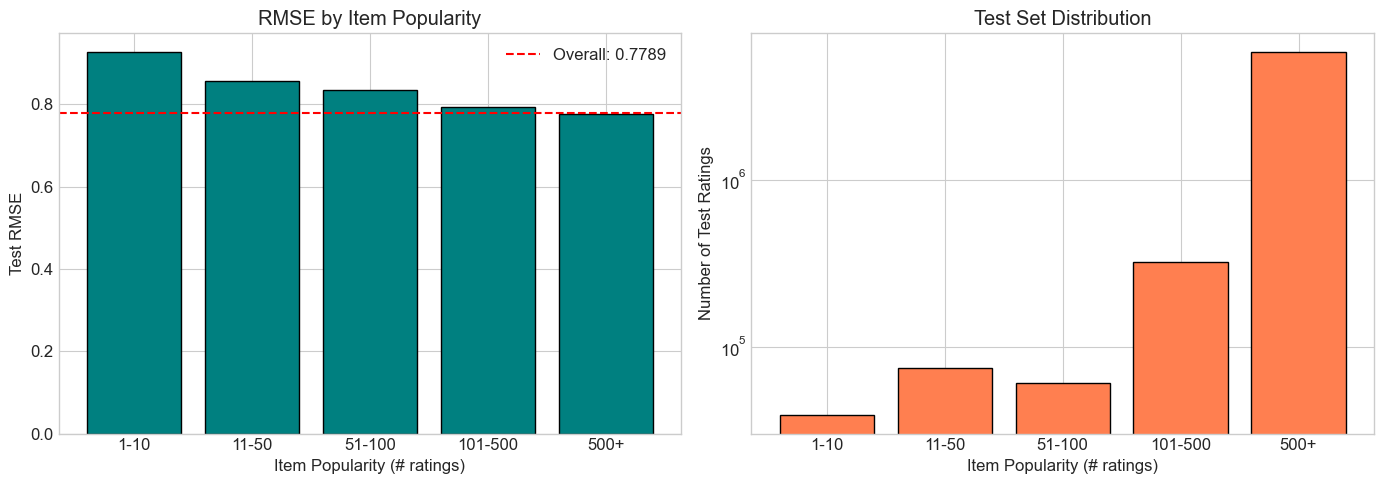

In [15]:
# Popularity bias visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(pop_df['bin'], pop_df['rmse'], color='teal', edgecolor='black')
ax.set_xlabel('Item Popularity (# ratings)')
ax.set_ylabel('Test RMSE')
ax.set_title('RMSE by Item Popularity')
ax.axhline(y=model_rand.test_rmse_history[-1], color='r', linestyle='--', 
           label=f'Overall: {model_rand.test_rmse_history[-1]:.4f}')
ax.legend()

ax = axes[1]
ax.bar(pop_df['bin'], pop_df['count'], color='coral', edgecolor='black')
ax.set_xlabel('Item Popularity (# ratings)')
ax.set_ylabel('Number of Test Ratings')
ax.set_title('Test Set Distribution')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'popularity_bias.pdf'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8: Bias vs Latent Factor Contribution

Compare the contribution of bias terms vs latent factors to prediction accuracy.

In [16]:
from src.bias_als import train_bias_als

print("Training bias-only model with optimal regularization...")
bias_user_biases, bias_item_biases, bias_global_mean, bias_loss_history, bias_train_rmse, bias_test_rmse = train_bias_als(
    rm_rand,
    n_iters=N_ITERS,
    lambda_=best_params_rand['lambda'],
    gamma=best_params_rand['gamma'],
    test_data=test_rand,
    verbose=True
)

mean_pred = np.mean(train_rand[2])
ss_total = np.sum((test_rand[2] - mean_pred) ** 2)

# Predict using bias-only model
bias_preds = bias_global_mean + bias_user_biases[test_rand[0]] + bias_item_biases[test_rand[1]]
ss_bias = np.sum((test_rand[2] - bias_preds) ** 2)
r2_bias = 1 - ss_bias / ss_total

full_preds = model_rand.predict(test_rand[0], test_rand[1])
ss_full = np.sum((test_rand[2] - full_preds) ** 2)
r2_full = 1 - ss_full / ss_total

latent_contribution = r2_full - r2_bias

print(f"\nBias-Only R²: {r2_bias:.4f}")
print(f"Full Model R²: {r2_full:.4f}")
print(f"Latent Factor Contribution: {latent_contribution:.4f}")

Training bias-only model with optimal regularization...
Iteration   1: Loss=14433.7344, Train RMSE=0.8622, Test RMSE=0.8687
Iteration   2: Loss=14015.3554, Train RMSE=0.8508, Test RMSE=0.8573
Iteration   3: Loss=13996.0119, Train RMSE=0.8503, Test RMSE=0.8568
Iteration   4: Loss=13991.6175, Train RMSE=0.8502, Test RMSE=0.8567
Iteration   5: Loss=13988.6620, Train RMSE=0.8502, Test RMSE=0.8567
Iteration   6: Loss=13986.3669, Train RMSE=0.8501, Test RMSE=0.8567
Iteration   7: Loss=13984.5579, Train RMSE=0.8501, Test RMSE=0.8566
Iteration   8: Loss=13983.1288, Train RMSE=0.8501, Test RMSE=0.8566
Iteration   9: Loss=13981.9991, Train RMSE=0.8501, Test RMSE=0.8566
Iteration  10: Loss=13981.1062, Train RMSE=0.8501, Test RMSE=0.8566
Iteration  11: Loss=13980.4003, Train RMSE=0.8500, Test RMSE=0.8566
Iteration  12: Loss=13979.8423, Train RMSE=0.8500, Test RMSE=0.8566
Iteration  13: Loss=13979.4012, Train RMSE=0.8500, Test RMSE=0.8566
Iteration  14: Loss=13979.0525, Train RMSE=0.8500, Test RMSE

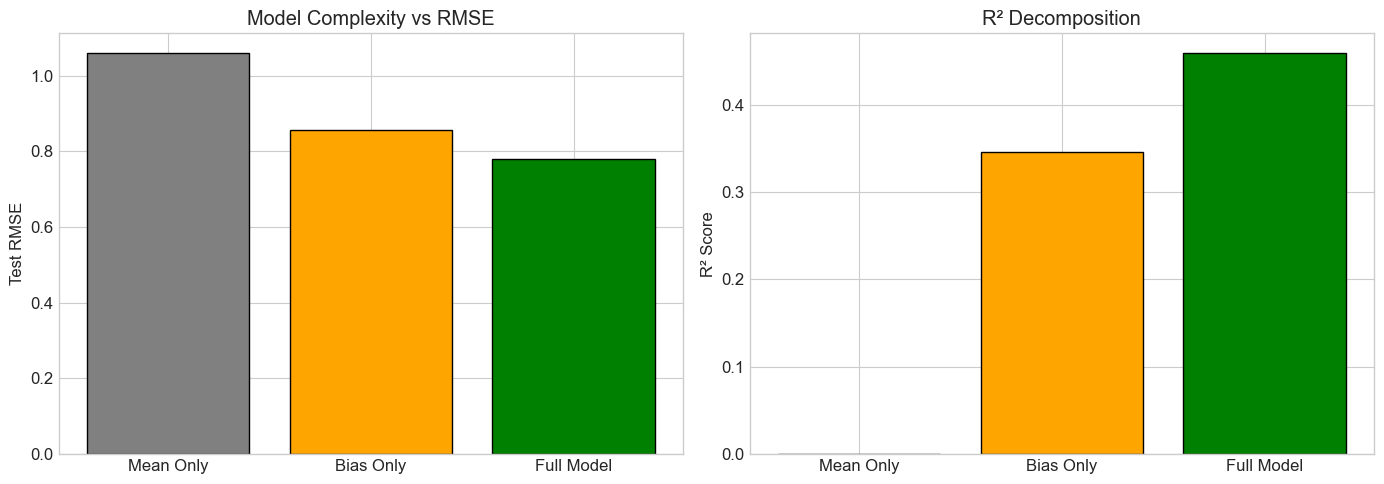

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Mean Only', 'Bias Only', 'Full Model']
# Use bias_test_rmse from train_bias_als output
rmses = [np.sqrt(ss_total / len(test_rand[2])), bias_test_rmse[-1], model_rand.test_rmse_history[-1]]
axes[0].bar(models, rmses, color=['gray', 'orange', 'green'], edgecolor='black')
axes[0].set_ylabel('Test RMSE')
axes[0].set_title('Model Complexity vs RMSE')

r2_values = [0, r2_bias, r2_full]
axes[1].bar(models, r2_values, color=['gray', 'orange', 'green'], edgecolor='black')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Decomposition')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'bias_vs_latent.pdf'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9: Latent Factor Embedding Analysis

Analyze the learned item embeddings using PCA visualization and correlation analysis.

In [18]:
# Analyze item embeddings
from sklearn.decomposition import PCA

# Get item factors from the best model
item_factors = model_rand.item_factors

# PCA on item embeddings
pca = PCA(n_components=2)
item_embeddings_2d = pca.fit_transform(item_factors)

print(f"Item embeddings shape: {item_factors.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

Item embeddings shape: (84432, 20)
Explained variance ratio: [0.12062836 0.07569539]
Total variance explained: 19.63%


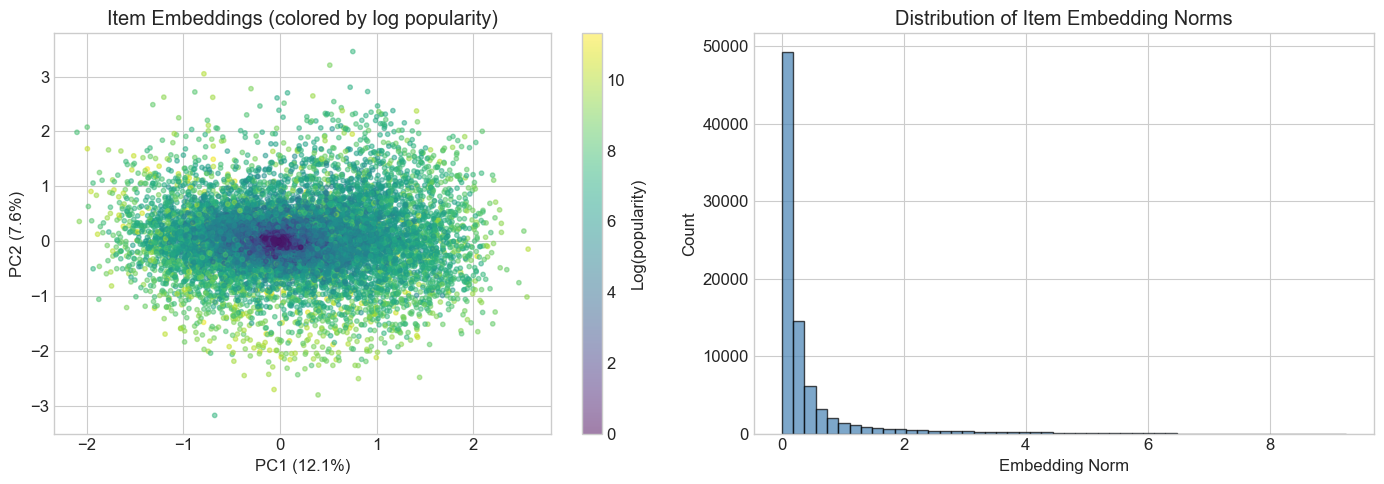

In [19]:
# PCA visualization colored by popularity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by log popularity
log_pop = np.log1p(item_counts)
scatter = axes[0].scatter(item_embeddings_2d[:, 0], item_embeddings_2d[:, 1], 
                          c=log_pop, cmap='viridis', alpha=0.5, s=10)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Item Embeddings (colored by log popularity)')
plt.colorbar(scatter, ax=axes[0], label='Log(popularity)')

# Embedding norm distribution
embedding_norms = np.linalg.norm(item_factors, axis=1)
axes[1].hist(embedding_norms, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Embedding Norm')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Item Embedding Norms')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'embedding_analysis.pdf'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Embedding norm vs popularity correlation
from scipy.stats import spearmanr

# Only for items with ratings
mask = item_counts > 0
corr, pval = spearmanr(embedding_norms[mask], item_counts[mask])
print(f"Spearman correlation (embedding norm vs popularity): {corr:.4f} (p={pval:.2e})")

# Correlation with item bias
item_biases = model_rand.item_biases
corr_bias, pval_bias = spearmanr(embedding_norms[mask], np.abs(item_biases[mask]))
print(f"Spearman correlation (embedding norm vs |item bias|): {corr_bias:.4f} (p={pval_bias:.2e})")

Spearman correlation (embedding norm vs popularity): 0.8528 (p=0.00e+00)
Spearman correlation (embedding norm vs |item bias|): 0.7062 (p=0.00e+00)


In [21]:
# Top polarizing items (highest embedding norms)
top_k = 20
top_indices = np.argsort(embedding_norms)[-top_k:][::-1]

print(f"\nTop {top_k} Polarizing Items (highest embedding norms):")
print("-" * 60)
for i, idx in enumerate(top_indices):
    item_id = dataset.item_ids[idx] if hasattr(dataset, 'item_ids') else idx
    print(f"{i+1:2d}. Item {item_id}: norm={embedding_norms[idx]:.4f}, "
          f"bias={item_biases[idx]:.4f}, popularity={item_counts[idx]}")


Top 20 Polarizing Items (highest embedding norms):
------------------------------------------------------------
 1. Item 7029: norm=9.2473, bias=0.5253, popularity=53951
 2. Item 4888: norm=9.0905, bias=0.5426, popularity=58656
 3. Item 5841: norm=9.0456, bias=0.4939, popularity=54048
 4. Item 285: norm=8.8238, bias=-0.3056, popularity=21203
 5. Item 228: norm=8.6905, bias=-0.5579, popularity=29539
 6. Item 2618: norm=8.6189, bias=-0.6014, popularity=18204
 7. Item 2537: norm=8.4384, bias=-0.3821, popularity=30427
 8. Item 13511: norm=8.1709, bias=0.1581, popularity=16818
 9. Item 5271: norm=8.1568, bias=-0.3754, popularity=21953
10. Item 257: norm=8.1060, bias=0.5205, popularity=67956
11. Item 9954: norm=8.1016, bias=-0.0743, popularity=19850
12. Item 15530: norm=8.0250, bias=0.1724, popularity=16680
13. Item 16704: norm=8.0248, bias=0.2552, popularity=16154
14. Item 11701: norm=7.9467, bias=0.1381, popularity=16908
15. Item 7744: norm=7.9203, bias=0.2365, popularity=25083
16. Item 1

---
## Section 10: Ablation Study Summary

In [22]:
print("=" * 60)
print("ABLATION STUDY SUMMARY")
print("=" * 60)

print("\n1. HPO COMPARISON:")
print(f"   Random Split - Best RMSE: {study_rand.best_value:.4f}")
print(f"   Time-Based Split - Best RMSE: {study_time.best_value:.4f}")

print("\n2. OPTIMAL HYPERPARAMETERS (Random Split):")
for k, v in best_params_rand.items():
    print(f"   {k}: {v:.6f}" if isinstance(v, float) else f"   {k}: {v}")

print("\n3. LATENT DIMENSION ANALYSIS:")
best_k_idx = k_df['test_rmse'].idxmin()
print(f"   Best K: {k_df.loc[best_k_idx, 'K']} (Test RMSE: {k_df.loc[best_k_idx, 'test_rmse']:.4f})")

print("\n4. BIAS vs LATENT CONTRIBUTION:")
print(f"   Bias-Only R²: {r2_bias:.4f}")
print(f"   Full Model R²: {r2_full:.4f}")
print(f"   Latent Factor Contribution: {latent_contribution:.4f}")

print("\n5. POPULARITY BIAS:")
print("   RMSE by popularity bin:")
for _, row in pop_df.iterrows():
    print(f"   {row['bin']}: {row['rmse']:.4f} ({row['count']:,} ratings)")

print("\n" + "=" * 60)

ABLATION STUDY SUMMARY

1. HPO COMPARISON:
   Random Split - Best RMSE: 0.7811
   Time-Based Split - Best RMSE: 0.9690

2. OPTIMAL HYPERPARAMETERS (Random Split):
   K: 20
   lambda: 0.001474
   tau: 0.012563
   gamma: 0.023346

3. LATENT DIMENSION ANALYSIS:
   Best K: 20 (Test RMSE: 0.7789)

4. BIAS vs LATENT CONTRIBUTION:
   Bias-Only R²: 0.3457
   Full Model R²: 0.4590
   Latent Factor Contribution: 0.1133

5. POPULARITY BIAS:
   RMSE by popularity bin:
   1-10: 0.9258 (38,646 ratings)
   11-50: 0.8575 (74,361 ratings)
   51-100: 0.8351 (60,602 ratings)
   101-500: 0.7939 (323,033 ratings)
   500+: 0.7751 (5,898,652 ratings)

